## 1. La legge dei grandi numeri

La legge dei grandi numeri è un teorema fondamentale della teoria della probabilità che indica che se ripetiamo molte volte (tendendo all'infinito) lo stesso esperimento, la frequenza di un certo evento tende ad essere costante.

Vale a dire, **la legge dei grandi numeri indica che se lo stesso test viene eseguito ripetutamente (ad esempio, lancio di una moneta), la frequenza con cui si ripeterà un determinato evento (testa/croce) si avvicinerà a una costante. Questa a sua volta sarà la probabilità che questo evento si verifichi.**

Fonte: https://it.economy-pedia.com/11038376-law-of-the-big-numbers

- Scrivere una funzione che simula il lancio di una moneta per N volte e restituisce la frequenza % di volte che è uscita testa.
- Calcolare la frequenza % con la grandezze del campione (numero di lanci) che varia 100 volte da 10 a 20000. Ottengo quindi 100 valori.
- Fare il plot del Numero medio di teste (y) rispetto alla grandezza del campione (x)





In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random as rd

In [ ]:
# 1
def lancio(N):
    array = np.random.randint(0,2,N)
    frequenza = array.sum()/N
    return frequenza

# 2
def random_len(N):
    percentuali = []
    len = np.arange(10, 20000, N)
    for l in len:
        percentuali.append(f'{round(lancio(l)*100, 2)} %')
    return percentuali


# 3


['50.0 %', '44.55 %', '51.43 %', '52.26 %', '51.95 %', '49.61 %', '50.66 %', '51.69 %', '49.63 %', '51.1 %', '49.11 %', '50.09 %', '49.42 %', '51.83 %', '49.57 %', '52.25 %', '48.94 %', '50.29 %', '51.71 %', '51.41 %', '49.05 %', '51.04 %', '50.54 %', '50.65 %', '50.25 %', '49.04 %', '49.77 %', '49.0 %', '50.14 %', '49.21 %', '48.97 %', '49.9 %', '50.12 %', '49.37 %', '51.03 %', '51.17 %', '49.39 %', '50.24 %', '51.36 %', '50.49 %', '49.65 %', '50.29 %', '50.1 %', '49.95 %', '49.91 %', '49.31 %', '50.78 %', '51.02 %', '49.46 %', '49.14 %', '50.14 %', '50.1 %', '49.88 %', '50.83 %', '49.56 %', '50.15 %', '49.48 %', '49.74 %', '50.14 %', '50.71 %', '51.6 %', '50.31 %', '48.66 %', '48.92 %', '50.22 %', '50.11 %', '50.39 %', '50.28 %', '50.19 %', '50.91 %', '49.73 %', '50.01 %', '48.39 %', '49.32 %', '49.11 %', '49.99 %', '50.67 %', '49.92 %', '49.86 %', '50.21 %', '50.11 %', '50.35 %', '50.17 %', '50.02 %', '49.73 %', '49.72 %', '49.42 %', '50.54 %', '50.65 %', '49.28 %', '50.28 %', '50.0

## 2. Analisi del Dataset Titanic
- Quante righe e colonne ha il dataset?
- Controlla quanti valori mancanti ci sono per colonna
- Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
- Controlla se ci sono righe duplicate
- Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
- Visualizza la distribuzione dell'età per classe
- Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne

In [9]:
# 📦 Caricamento del dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Quante righe e colonne ha il dataset?
df.shape

(891, 12)

In [12]:
# Controlla quanti valori mancanti ci sono per colonna
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [15]:
# Riempi i valori mancanti nella colonna 'Embarked' con il valore più frequente
most_common = df['Embarked'].mode()[0]
df['Embarked'] = df['Embarked'].fillna(most_common)
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         0
dtype: int64

In [ ]:
# Controlla se ci sono righe duplicate
df.duplicated().sum()  # non ci sono duplicati

np.int64(0)

In [20]:
# Calcola l'età media dei passeggeri per ogni classe (`Pclass`), se ci sono valori mancanti di età nella colonna 'Age' riempili con il valore medio
mean_common_age = df['Age'].mean()
df['Age'] = df['Age'].fillna(mean_common_age)
df.groupby('Pclass')['Age'].mean()

Pclass
1    37.048118
2    29.866958
3    26.403259
Name: Age, dtype: float64

<Axes: xlabel='Pclass', ylabel='Age'>

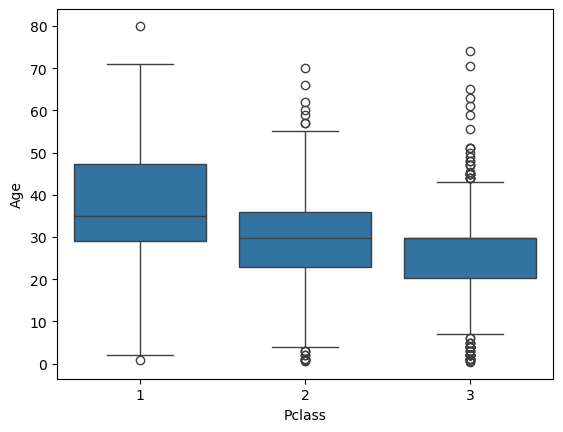

In [23]:
# Visualizza la distribuzione dell'età per classe
sns.boxplot(data=df, x='Pclass', y ='Age')

<Axes: xlabel='Pclass', ylabel='Age'>

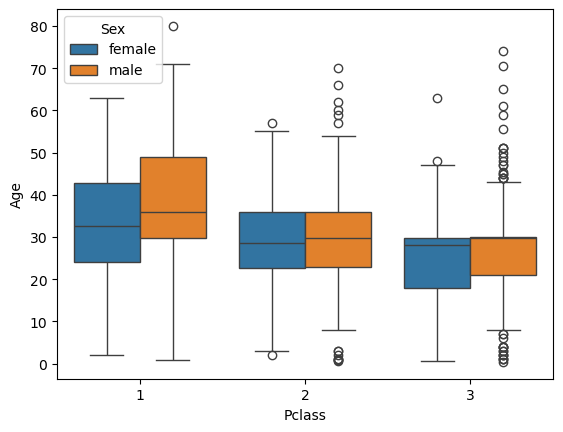

In [22]:
# Visualizza la distribuzione dell'età per classe dividendo e mostrando insieme i dati di uomini e donne
sns.boxplot(data=df, x='Pclass', y ='Age', hue='Sex')

## 3. Analisi del Dataset Iris

- Esplora la distribuzione delle specie (conta quanti campioni ci sono per specie)
- Calcola la lunghezza e la larghezza media dei petali per specie
- Visualizza le dimensioni dei petali per specie (scatterplot)
- Crea una nuova colonna per l'area del petalo e analizzala
- Grafico della distribuzione dell'area del petalo per specie (boxplot)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)
df.head()